In [1]:
import os
import time
import joblib
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, accuracy_score
from lightgbm import LGBMClassifier

import warnings

# OPTUNA
import optuna

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

/home/placivm_tfg/PLACI_TFG/.venv_tfg/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 1. CARGA
# ==========================================
path_df = "../../DATASETS/dataSets_Reducidos/ton_iot/datos_TON_IoT_redux.csv"

df = pl.read_csv(path_df)

print(df.shape)
print(df.head())

# ==========================================
# 2. LIMPIEZA
# ==========================================
df = df.drop_nulls()

# ==========================================
# 3. SEPARAR TARGET Y FEATURES
# ==========================================

target_col = "label"

cols_to_drop = [
    "label",
    "type",
    "src_ip",
    "dst_ip"
]

X = df.drop(cols_to_drop).to_pandas()
y = df[target_col].to_numpy()

# ==========================================
# 4. SPLIT 80/20
# ==========================================

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# 5. SPLIT TRAIN / VALIDACIÓN
# ==========================================

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=42,
    stratify=y_train_full
)

# ==========================================
# 6. PREPROCESAMIENTO
# ==========================================

categorical_cols = ["proto", "conn_state"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_cols),
    ]
)

# Transformar
X_train_np = preprocessor.fit_transform(X_train)
X_val_np = preprocessor.transform(X_val)
X_test_np = preprocessor.transform(X_test)

# También necesitamos transformar el conjunto completo de entrenamiento para cross-validation
X_full_train_np = preprocessor.transform(X_train_full)
y_full_train = y_train_full
y_test_np = y_test

print("Shapes:")
print("Train:", X_train_np.shape)
print("Val:", X_val_np.shape)
print("Test:", X_test_np.shape)

(211043, 13)
shape: (5, 13)
┌──────────────┬──────────┬──────────────┬──────────┬───┬──────────┬────────────┬───────┬──────────┐
│ src_ip       ┆ src_port ┆ dst_ip       ┆ dst_port ┆ … ┆ dst_pkts ┆ conn_state ┆ label ┆ type     │
│ ---          ┆ ---      ┆ ---          ┆ ---      ┆   ┆ ---      ┆ ---        ┆ ---   ┆ ---      │
│ str          ┆ i64      ┆ str          ┆ i64      ┆   ┆ i64      ┆ str        ┆ i64   ┆ str      │
╞══════════════╪══════════╪══════════════╪══════════╪═══╪══════════╪════════════╪═══════╪══════════╡
│ 192.168.1.37 ┆ 4444     ┆ 192.168.1.19 ┆ 49178    ┆ … ┆ 31       ┆ OTH        ┆ 1     ┆ backdoor │
│              ┆          ┆ 3            ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1        ┆ REJ        ┆ 1     ┆ backdoor │
│ 3            ┆          ┆              ┆          ┆   ┆          ┆            ┆       ┆          │
│ 192.168.1.19 ┆ 49180    ┆ 192.168.1.37 ┆ 8080     ┆ … ┆ 1    

In [ ]:
# ==========================================
# 2. FASE 1: OPTUNA + 3-FOLD CV (ESTRUCTURA REAL)
# ==========================================

# Convertir -1/1 a 0/1 ANTES de entrar a Optuna
y_full_train_01 = ((y_full_train + 1) // 2).astype(np.int8)


def objective(trial):

    warnings.filterwarnings("ignore", category=UserWarning)
    
    n_estimators = trial.suggest_int("n_estimators", 50, 600, step=50)
    num_leaves = trial.suggest_int("num_leaves", 15, 255) 
    max_depth = trial.suggest_int("max_depth", 3, 12)    
    
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42) 
    f1_scores = []
    latencies = []

    for train_idx, val_idx in skf.split(X_full_train_np, y_full_train_01):
        X_train_cv, X_val_cv = X_full_train_np[train_idx], X_full_train_np[val_idx]
        y_train_cv, y_val_cv = y_full_train_01[train_idx], y_full_train_01[val_idx]

        model = LGBMClassifier(
            n_estimators=n_estimators,
            num_leaves=num_leaves,
            max_depth=max_depth,
            learning_rate=0.1,  
            objective="binary", 
            device_type="cpu",
            n_jobs=-1,          
            random_state=42,
            verbosity=-1        
        )

        model.fit(X_train_cv, y_train_cv)
        model.set_params(device_type="cpu")

        # 1. Medir Eficacia
        y_pred = model.predict(X_val_cv)
        f1_scores.append(f1_score(y_val_cv, y_pred, average="macro"))

        # 2. Medir Eficiencia dentro de cada fold
        subset = min(20000, len(X_val_cv))
        X_lat = X_val_cv[:subset]

        # Warm-up rápido
        _ = model.predict(X_lat[:500])

        rep_lat = []
        for _ in range(5):
            t0 = time.perf_counter()
            _ = model.predict(X_lat)
            t1 = time.perf_counter()
            rep_lat.append((t1 - t0) / len(X_lat) * 1000)

        latencies.append(float(np.mean(rep_lat)))

    avg_lat = float(np.mean(latencies))
    avg_f1 = float(np.mean(f1_scores))
    trial.set_user_attr("f1_std", float(np.std(f1_scores)))

    return avg_f1, avg_lat

# Ejecución del estudio
study = optuna.create_study(directions=["maximize", "minimize"], study_name="lgbm_iot_ids_optimization")
print("🚀 Iniciando barrido multiobjetivo con LightGBM...")
study.optimize(objective, n_trials=50)

# ==========================================
# 3. EXPORTACIÓN Y VISUALIZACIÓN PARETO
# ==========================================

pareto_ids = {t.number for t in study.best_trials}
trials_data = []
for t in study.trials:
    if t.state == optuna.trial.TrialState.COMPLETE:
        trials_data.append({
            "n_estimators": t.params["n_estimators"],
            "num_leaves": t.params["num_leaves"],
            "max_depth": t.params["max_depth"],
            "f1_macro": t.values[0],
            "f1_std": t.user_attrs["f1_std"],
            "latency_ms": t.values[1],
            "is_pareto": t.number in pareto_ids
        })

df_results = pl.DataFrame(trials_data)
df_results.write_csv("lgbm_iot_trials_results_cv.csv")

[I 2026-04-29 21:45:32,095] A new study created in memory with name: lgbm_iot_ids_optimization


🚀 Iniciando barrido multiobjetivo con LightGBM...


[I 2026-04-29 21:45:36,347] Trial 0 finished with values: [0.9960931754517005, 0.0004455526894889772] and parameters: {'n_estimators': 500, 'num_leaves': 32, 'max_depth': 6}.
[I 2026-04-29 21:45:39,467] Trial 1 finished with values: [0.9961429624148752, 0.0003731022245483473] and parameters: {'n_estimators': 450, 'num_leaves': 85, 'max_depth': 5}.
[I 2026-04-29 21:45:40,102] Trial 2 finished with values: [0.9939056517215691, 0.00015262581990100444] and parameters: {'n_estimators': 100, 'num_leaves': 237, 'max_depth': 4}.
[I 2026-04-29 21:45:46,104] Trial 3 finished with values: [0.9961252269972796, 0.0005458493396872655] and parameters: {'n_estimators': 250, 'num_leaves': 156, 'max_depth': 9}.
[I 2026-04-29 21:45:48,176] Trial 4 finished with values: [0.9959957277146624, 0.00025870393554214386] and parameters: {'n_estimators': 250, 'num_leaves': 168, 'max_depth': 5}.
[I 2026-04-29 21:45:49,850] Trial 5 finished with values: [0.9960206161116896, 0.0003189165092771873] and parameters: {'

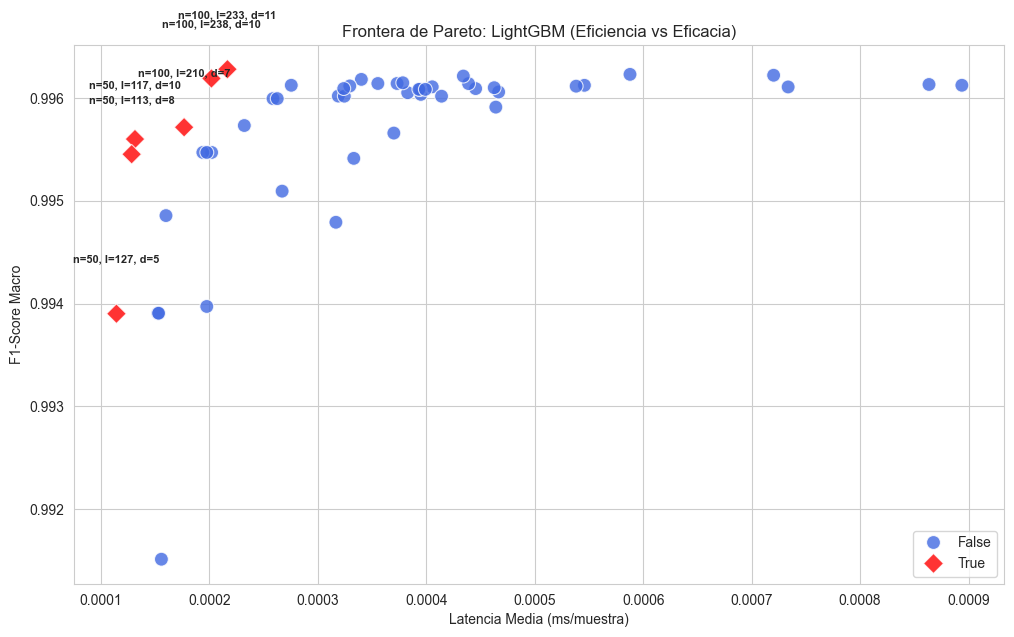

In [4]:
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
sns.scatterplot(
    x=df_results["latency_ms"].to_numpy(),
    y=df_results["f1_macro"].to_numpy(),
    hue=df_results["is_pareto"].to_numpy(),
    palette={True: "red", False: "royalblue"},
    style=df_results["is_pareto"].to_numpy(),
    markers={True: "D", False: "o"}, s=100, alpha=0.8
)

# Anotación de puntos Pareto
pareto_points = df_results.filter(pl.col("is_pareto") == True)
for row in pareto_points.iter_rows(named=True):
    plt.text(row["latency_ms"], row["f1_macro"] + 0.0005, 
             f"n={int(row['n_estimators'])}, l={int(row['num_leaves'])}, d={int(row['max_depth'])}", 
             fontsize=8, fontweight='bold', ha='center')

plt.title("Frontera de Pareto: LightGBM (Eficiencia vs Eficacia)")
plt.xlabel("Latencia Media (ms/muestra)")
plt.ylabel("F1-Score Macro")
plt.show()

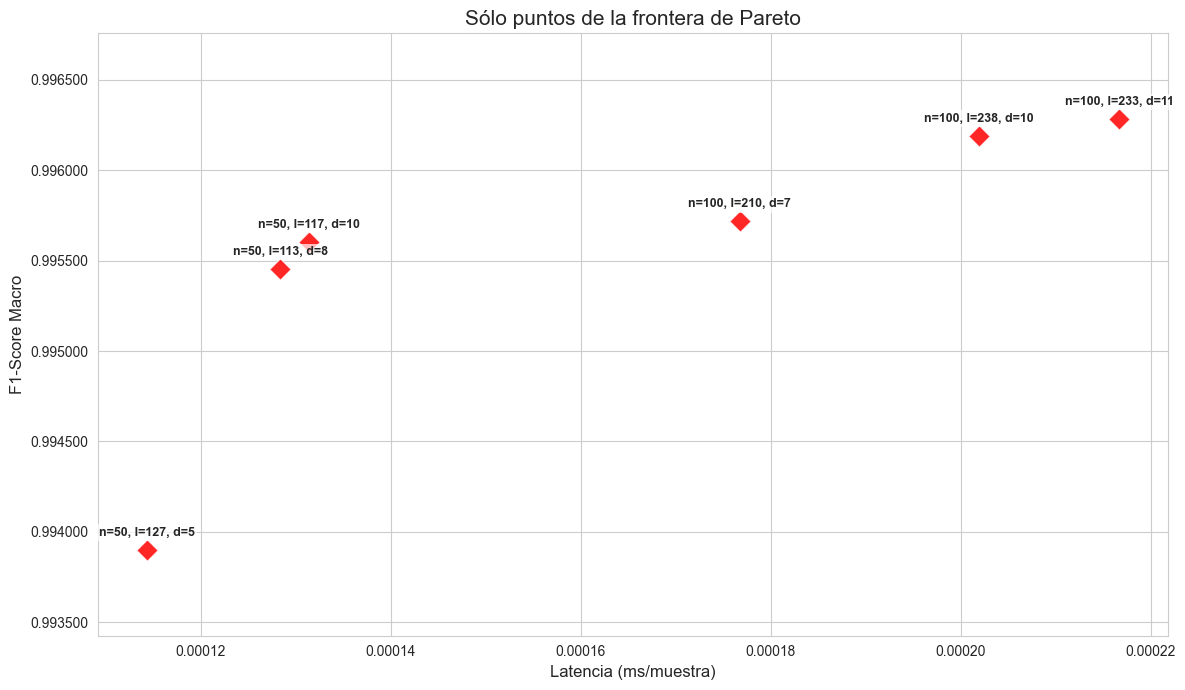

n_estimators,num_leaves,max_depth,f1_macro,f1_std,latency_ms,is_pareto
i64,i64,i64,f64,f64,f64,bool
50,127,5,0.993901,0.000513,0.000114,true
50,113,8,0.995454,0.000039,0.000128,true
50,117,10,0.995602,0.000105,0.000131,true
100,210,7,0.995717,0.00004,0.000177,true
100,238,10,0.996192,0.00004,0.000202,true
100,233,11,0.996282,0.000113,0.000217,true


In [5]:
# representamos únicamente los puntos que forman la frontera de Pareto

from matplotlib.ticker import FormatStrFormatter

# 1. cargamos los resultados y filtramos
df = pl.read_csv("lgbm_iot_trials_results_cv.csv")
pareto = (
    df
    .filter(pl.col("is_pareto") == True)
    .sort("latency_ms")
)

# 2. estilo
plt.figure(figsize=(12, 7))
sns.set_style("whitegrid")
ax = plt.gca()

# 3. dibujamos sólo los puntos de Pareto
sns.scatterplot(
    x=pareto["latency_ms"].to_numpy(),
    y=pareto["f1_macro"].to_numpy(),
    color="red",
    marker="D",
    s=120,
    alpha=0.85,
    ax=ax
)

# Evitamos el formato raro del eje Y cuando los F1 están muy cerca de 1.0
ax.ticklabel_format(style='plain', axis='y', useOffset=False)
ax.yaxis.set_major_formatter(FormatStrFormatter('%.6f'))

# Añadimos un pequeño margen vertical para que respiren los puntos
y_vals = pareto["f1_macro"].to_numpy()
if len(y_vals) > 0:
    y_min = float(y_vals.min())
    y_max = float(y_vals.max())
    margin = max((y_max - y_min) * 0.2, 0.00005)
    ax.set_ylim(y_min - margin, y_max + margin)

# 4. anotamos cada punto pegado a su marca roja
for row in pareto.iter_rows(named=True):
    ax.annotate(
        f"n={int(row['n_estimators'])}, l={int(row['num_leaves'])}, d={int(row['max_depth'])}",
        xy=(row["latency_ms"], row["f1_macro"]),
        xytext=(0, 8),
        textcoords='offset points',
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1.5)
    )

# 5. etiquetas
plt.title("Sólo puntos de la frontera de Pareto", fontsize=15)
plt.xlabel("Latencia (ms/muestra)", fontsize=12)
plt.ylabel("F1-Score Macro", fontsize=12)
plt.tight_layout()
plt.show()

# Mostramos los puntos de Pareto
display(pareto)

In [6]:
# ==========================================
# 4. FASE 3: EVALUACIÓN FINAL EN TEST
# ==========================================

# Aquí deberás ajustar estos candidatos con los que veas en ROJO en tu gráfica
candidatos = [
    {"n": 50, "l": 127, "d": 5,  "nombre": "Candidato 1"},
    {"n": 50, "l": 113, "d": 8,  "nombre": "Candidato 2"},
    {"n": 50, "l": 117, "d": 10, "nombre": "Candidato 3"},
    {"n": 100, "l": 210, "d": 7, "nombre": "Candidato 4"},
    {"n": 100, "l": 238, "d": 10, "nombre": "Candidato 5"},
    {"n": 100, "l": 233, "d": 11, "nombre": "Candidato 6"},
]

resultados_finales = []

print("\n--- EVALUACIÓN FINAL SOBRE TEST (COHERENTE) ---")
for c in candidatos:
    model_final = LGBMClassifier(
        n_estimators=c["n"],
        num_leaves=c["l"],
        max_depth=c["d"],
        learning_rate=0.1, # Coherencia con la Fase 1
        device_type="gpu",
        n_jobs=-1,
        random_state=42,
        verbosity=-1
    )
    
    model_final.fit(X_full_train_np, y_full_train_01)
    model_final.set_params(device_type="cpu")
    
    # Medición de latencia real en Test (5 pasadas)
    t_start = time.perf_counter()
    y_test_pred = model_final.predict(X_test_np)
    t_end = time.perf_counter()
    
    resultados_finales.append({
        "Perfil": c["nombre"],
        "n_est": c["n"],
        "leaves": c["l"],
        "depth": c["d"],
        "F1_Test": f1_score(y_test_np, y_test_pred, average="macro"),
        "Acc_Test": accuracy_score(y_test_np, y_test_pred),
        "Latencia_ms": ((t_end - t_start) / len(X_test_np)) * 1000
    })

df_final = pl.DataFrame(resultados_finales)
print("\n", df_final)


--- EVALUACIÓN FINAL SOBRE TEST (COHERENTE) ---

 shape: (6, 7)
┌─────────────┬───────┬────────┬───────┬──────────┬──────────┬─────────────┐
│ Perfil      ┆ n_est ┆ leaves ┆ depth ┆ F1_Test  ┆ Acc_Test ┆ Latencia_ms │
│ ---         ┆ ---   ┆ ---    ┆ ---   ┆ ---      ┆ ---      ┆ ---         │
│ str         ┆ i64   ┆ i64    ┆ i64   ┆ f64      ┆ f64      ┆ f64         │
╞═════════════╪═══════╪════════╪═══════╪══════════╪══════════╪═════════════╡
│ Candidato 1 ┆ 50    ┆ 127    ┆ 5     ┆ 0.99456  ┆ 0.996067 ┆ 0.00011     │
│ Candidato 2 ┆ 50    ┆ 113    ┆ 8     ┆ 0.996134 ┆ 0.997204 ┆ 0.000113    │
│ Candidato 3 ┆ 50    ┆ 117    ┆ 10    ┆ 0.996299 ┆ 0.997323 ┆ 0.000298    │
│ Candidato 4 ┆ 100   ┆ 210    ┆ 7     ┆ 0.996594 ┆ 0.997536 ┆ 0.000181    │
│ Candidato 5 ┆ 100   ┆ 238    ┆ 10    ┆ 0.996955 ┆ 0.997797 ┆ 0.000191    │
│ Candidato 6 ┆ 100   ┆ 233    ┆ 11    ┆ 0.997085 ┆ 0.997891 ┆ 0.000202    │
└─────────────┴───────┴────────┴───────┴──────────┴──────────┴─────────────┘
